# 统一数据预处理 Notebook

请在下面的**参数配置单元格**中调整参数，然后运行所有单元格。

## 配置说明

| 参数 | 说明 | 可选值 |
|------|------|--------|
| `NORMALIZATION_TYPE` | 归一化方式 | `'column'` (列归一), `'global'` (全局归一) |
| `USE_SEND` | 是否使用send处理 | `True`, `False` |
| `USE_5K` | 是否使用5k样本模式 | `True`, `False` |
| `MASK_LOW_FREQ` | 是否屏蔽低频区域 | `True`, `False` |
| `INCLUDE_ORIGINAL` | 是否包含原始数据（无增强） | `True`, `False` |
| `MERGE_LABELS` | 标签合并配置 | 字典或 `None` |
| `OUTPUT_SUFFIX` | 输出文件名后缀 | 字符串 |

In [3]:
# ==========================================
# 参数配置区域 - 在此修改所有配置参数
# ==========================================

# ---- 数据路径配置 ----
folder_path_list = [
    "G:\\Files\\HW\\第三阶段\\github\mobileNet_v3\\data\\新数据集-添加脉冲噪声\\噪音数据集",
    "G:\\Files\\HW\\第三阶段\\github\mobileNet_v3\\data\\新数据集-添加脉冲噪声\\快艇",  
    "G:\\Files\\HW\\第三阶段\\github\mobileNet_v3\\data\\新数据集-添加脉冲噪声\\海豚", 
    "G:\\Files\\HW\\第三阶段\\github\mobileNet_v3\\data\\新数据集-添加脉冲噪声\\伪虎鲸"
]
# folder_path_list = [
#     "G:\\Files\\HW\\HW_ResNet\\极地海洋世界录音\\噪音数据集-浮标",
#     "G:\\Files\\HW\\HW_ResNet\\极地海洋世界录音\\快艇数据集",  
#     "G:\\Files\\HW\\HW_ResNet\\极地海洋世界录音\\瓶鼻海豚数据集", 
#     "G:\\Files\\HW\\HW_ResNet\\极地海洋世界录音\\伪虎鲸数据集"
# ]

# ---- 基础参数配置 ----
Temp_sample_num = 20000      # 预分配的大数组尺寸
Sample_time_len = 2          # 单个样本的时间长度（秒）
window_length_s = 0.02       # STFT窗长（秒）
overlap_ratio = 0.0          # STFT窗重叠比例
overlap_ratio_frame = 0.5    # 样本重叠比例
frequency_choose_low = 3e3   # 关注的频率范围下限（Hz）
frequency_choose_high = 13e3 # 关注的频率范围上限（Hz）
output_channel = 1           # 输出通道数

# ---- 数据增强参数配置 ----
Add_snr = 4               # 额外SNR增加值（用于特定类别）
Add_snr_1 = 8
loop_num = 5                # 噪声增强循环次数
SNR_dB_begin = 8            # 初始SNR值（dB）
loss_SNR = 3        # 每次循环SNR递减值
group_d_loop_num = 3         # group_d_send数量（固定为3，对应3个group_d_send数组）

# ---- 处理方式配置 ----
NORMALIZATION_TYPE = 'global'    # 'column' = 列归一, 'global' = 全局归一
USE_SEND = False                  # True = 使用send处理, False = 不使用
USE_5K = False                   # True = 5k版本(样本扩增), False = 标准版本
INCLUDE_ORIGINAL = False          # True = 包含原始数据（无group_d_send变换）

# ---- 频段处理配置（仅列归一+withsend+5k版本使用） ----
MASK_LOW_FREQ = False            # True = 屏蔽低频(0:40行置为接近0), False = 不屏蔽
MASK_VALUE = 1e-8                # 低频屏蔽值

# ---- 标签合并配置 ----
# 格式: {目标值: [要合并的原始值列表]}
# 例如: {0: [1]} 表示将标签1合并到标签0
# 设置为 None 表示不进行标签合并

# MERGE_LABELS = {0: [1]}          # 将标签1合并到标签0
MERGE_LABELS =None         # 将标签1合并到标签0

# ---- 输出文件名配置 ----
# 文件名格式: X_train_{Sample_time_len}_{OUTPUT_SUFFIX}.npy
# 如果为None，则根据配置自动生成后缀
OUTPUT_SUFFIX = None

# ---- 数据集平衡配置 ----
BALANCE_DATASET = True           # 是否进行数据集平衡
BALANCE_REMOVE_RATIO = {         # 各标签删除比例
    0: 0.2,  # 标签0删除10%
}

# ==========================================
# 自动生成输出文件名后缀（如果未手动指定）
# ==========================================
if OUTPUT_SUFFIX is None:
    parts = []
    if USE_5K:
        parts.append('5k')
    if USE_SEND:
        parts.append('withsend')
    if MASK_LOW_FREQ:
        parts.append('mask')
    else:
        parts.append('nomask')
    if NORMALIZATION_TYPE == 'column':
        parts.append('lieguiyi')
    elif NORMALIZATION_TYPE == 'global':
        parts.append('quanjuguiyi')
    OUTPUT_SUFFIX = '_'.join(parts) if parts else 'standard'

print(f"配置完成！输出文件名后缀: {OUTPUT_SUFFIX}")
print(f"归一化方式: {'列归一' if NORMALIZATION_TYPE == 'column' else '全局归一'}")
print(f"使用send处理: {USE_SEND}")
print(f"5k模式: {USE_5K}")
print(f"低频屏蔽: {MASK_LOW_FREQ}")
print(f"包含原始数据: {INCLUDE_ORIGINAL}")

配置完成！输出文件名后缀: nomask_quanjuguiyi
归一化方式: 全局归一
使用send处理: False
5k模式: False
低频屏蔽: False
包含原始数据: False


In [4]:
# 导入必要的库
import os
import numpy as np
import torchvision
import sys
from sklearn.model_selection import train_test_split
import csv
import sklearn.metrics as sm
import time
import torch
from torch import nn
from torch.nn import functional as F
from torchvision import transforms
from torch.utils import data
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset, DataLoader
import math
import scipy.io.wavfile
from scipy.signal import stft
from scipy.ndimage import zoom
from scipy import ndimage
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.io.wavfile import read
from scipy.io import wavfile
import random
from scipy import interpolate
import gc
from typing import Tuple, Optional

# 统计文件数量
files_all_num = 0
for folder_path in folder_path_list:
    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    num_files = len(wav_files)
    files_all_num = files_all_num + num_files
    print(f'{folder_path}文件夹下，共有 {num_files} 个文件。')

# 定义归一化函数
def normalize_columns_to_255_vectorized(X):
    """
    向量化版本：将输入的2D数组按列归一化到[0, 255]范围
    """
    if len(X.shape) != 2:
        raise ValueError("输入必须是2D数组")
    
    # 计算每列的最小值和最大值
    min_vals = np.min(X, axis=0, keepdims=True)
    max_vals = np.max(X, axis=0, keepdims=True)
    
    # 避免除零
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1
    
    # 归一化到[0, 255]
    X_normalized = ((X - min_vals) / (range_vals + 1e-8)) * 255
    
    return X_normalized

def normalize_global_to_255(X):
    """
    全局归一化：将输入数组全局归一化到[0, 255]范围
    """
    X_min, X_max = np.min(X), np.max(X)
    X_normalized = ((X - X_min) / (X_max - X_min + 1e-8)) * 255
    return X_normalized

# 根据配置选择归一化函数
def normalize_data(X):
    if NORMALIZATION_TYPE == 'column':
        return normalize_columns_to_255_vectorized(X)
    else:
        return normalize_global_to_255(X)
    
def add_impulse_noise(audio_data, Fs, impulse_prob=0.3, impulse_strength=0.5,
                      impulse_duration_ms_range=(0.5, 3.0), max_impulses_per_second=2):
    """
    在时域信号中添加脉冲噪声，模拟碰撞、机械冲击等瞬态干扰。
    
    物理特性：
    - 碰撞是瞬态事件，在时域表现为幅度大、持续极短的冲击；
    - 在STFT时频图上表现为贯穿全频带的垂直条纹（宽频特性）。
    """
    if np.random.rand() > impulse_prob:
        return audio_data
    
    # 转为float64避免整型溢出
    audio_float = audio_data.astype(np.float64)
    signal_max = np.max(np.abs(audio_float))
    if signal_max < 1e-10:
        return audio_data
    
    # 随机生成脉冲持续时间（采样点数）
    duration_ms = np.random.uniform(*impulse_duration_ms_range)
    duration_samples = max(1, int(Fs * duration_ms / 1000))
    
    # 计算该段信号应添加的脉冲总数
    signal_duration_sec = len(audio_float) / Fs
    max_impulses = max(1, int(signal_duration_sec * max_impulses_per_second))
    num_impulses = np.random.randint(1, max_impulses + 1)
    
    # 随机选择脉冲中心位置（避开信号边缘）
    margin = duration_samples * 3
    if len(audio_float) <= 2 * margin:
        return audio_data
    positions = np.random.randint(margin, len(audio_float) - margin, size=num_impulses)
    
    for pos in positions:
        # 随机极性和强度波动（模拟不同碰撞力度）
        sign = np.random.choice([-1, 1])
        strength = impulse_strength * np.random.uniform(0.4, 1.5)
        amplitude = signal_max * strength * sign
        
        # 生成指数衰减脉冲（更符合碰撞的物理衰减过程）
        t = np.arange(duration_samples)
        envelope = np.exp(-5 * t / duration_samples)  # 快速衰减
        pulse = amplitude * envelope
        
        # 叠加到信号
        end_pos = min(pos + duration_samples, len(audio_float))
        actual_len = end_pos - pos
        audio_float[pos:end_pos] += pulse[:actual_len]
    
    # 若原始为整数类型，进行限幅并还原类型
    if np.issubdtype(audio_data.dtype, np.integer):
        info = np.iinfo(audio_data.dtype)
        audio_float = np.clip(audio_float, info.min, info.max)
        return audio_float.astype(audio_data.dtype)
    
    return audio_float.astype(np.float32)
# ==========================================
# 平滑随机扰动生成函数（替代高斯白噪声）
# ==========================================

def smooth_gp_noise(n, std, length_scale=0.05):
    """
    高斯过程（RBF核）平滑扰动。
    length_scale 控制频率域相关长度（越大越平滑）。
    """
    x = np.linspace(0, 1, n)
    dist_sq = ((x[:, None] - x[None, :]) / length_scale) ** 2
    K = np.exp(-0.5 * dist_sq) + 1e-6 * np.eye(n)
    L = np.linalg.cholesky(K)
    z = np.random.randn(n)
    y = L @ z
    if np.std(y) > 1e-9:
        y = y / np.std(y) * std
    return y

G:\Files\HW\第三阶段\github\mobileNet_v3\data\新数据集-添加脉冲噪声\噪音数据集文件夹下，共有 2 个文件。
G:\Files\HW\第三阶段\github\mobileNet_v3\data\新数据集-添加脉冲噪声\快艇文件夹下，共有 1512 个文件。
G:\Files\HW\第三阶段\github\mobileNet_v3\data\新数据集-添加脉冲噪声\海豚文件夹下，共有 1481 个文件。
G:\Files\HW\第三阶段\github\mobileNet_v3\data\新数据集-添加脉冲噪声\伪虎鲸文件夹下，共有 1515 个文件。


In [5]:
# ==========================================
# 音频数据处理和STFT转换
# ==========================================

# 计算STFT后的时频矩阵维度
nfft = 1024
if overlap_ratio == 0:
    time_bins = np.floor(Sample_time_len / window_length_s)
else:
    time_bins = np.floor((Sample_time_len - window_length_s) / (window_length_s * (1 - overlap_ratio))) + 2

freq_bins = np.floor((frequency_choose_high - frequency_choose_low) * (nfft/48000))
time_bins, freq_bins = int(time_bins), int(freq_bins)
print(f'时频矩阵维度：时间轴 {time_bins}，频率轴 {freq_bins}')

# 预初始化数据矩阵和标签矩阵
data_matrix = np.zeros((Temp_sample_num, freq_bins, time_bins, output_channel))
label_matrix = np.zeros((Temp_sample_num, 1), dtype=np.uint8)
signal_len = np.zeros((files_all_num, 4))

# 计算频率范围的索引

Time_end_index = time_bins

# 样本和标签的当前索引
sample_idex = 0
label_idex = 0
all_time = 0
temp_1 = 0
signal_one = 0
file_one = -1

# 遍历每个文件夹处理音频文件
for folder_path in folder_path_list:
    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    num_files = len(wav_files)
    file_one = file_one + 1 
    
    for idx, wav_file in enumerate(wav_files):
        file_path = os.path.join(folder_path, wav_file)
        Fs, audio_data = wavfile.read(file_path)
        t_old = np.arange(len(audio_data)) / Fs
        # 新时间轴
        target_Fs = 48000
        num_samples = int(len(audio_data) * target_Fs / Fs)
        audio_data = signal.resample(audio_data, num_samples)
        Fs = target_Fs  # 后续所有参数按新的 Fs 计算


        all_time = all_time + len(audio_data)/Fs
        signal_duration = len(audio_data) / Fs
        sample_step = Sample_time_len * (1 - overlap_ratio_frame)
        frame_num = np.floor((signal_duration - Sample_time_len) / sample_step) + 1
        
        signal_len[signal_one, file_one] = signal_duration
        signal_one = signal_one + 1

        if frame_num >= 1:
            window_len = int(window_length_s * Fs)
            window_overlap = int(overlap_ratio * window_len)
            nfft = 1024 
            f, t, Zxx = stft(audio_data, fs=Fs, window='hamming', 
                            nperseg=window_len, noverlap=window_overlap, nfft=nfft)
            Frequency_start_index = np.argmin(np.abs(f - (frequency_choose_low)))
            Frequency_end_index = Frequency_start_index + freq_bins

            stft_time_resolution = t[1] - t[0]
            samples_per_frame = int(Sample_time_len / stft_time_resolution)
            
            for frame_one in range(int(frame_num)):
                start_time = frame_one * sample_step
                end_time = start_time + Sample_time_len
                
                start_idx = np.argmin(np.abs(t - start_time))
                end_idx = start_idx + samples_per_frame
                
                if end_idx <= len(t):
                    X_temp = np.abs(Zxx[Frequency_start_index:Frequency_end_index, 
                                      start_idx:end_idx])
                    
                    # 应用低频屏蔽（如果启用）
                    if MASK_LOW_FREQ:
                        X_temp[0:40, :] = MASK_VALUE
                    
                    if X_temp.shape[1] < time_bins:
                        padding = time_bins - X_temp.shape[1]
                        X_temp = np.pad(X_temp, ((0, 0), (0, padding)), mode='constant')
                    
                    # 应用归一化
                    X_temp = normalize_data(X_temp)
                    
                    if sample_idex < Temp_sample_num:
                        data_matrix[sample_idex, :, :, 0] = X_temp
                        label_matrix[sample_idex, 0] = label_idex
                        sample_idex += 1
    
    print(f'{folder_path}处理完成，共处理 {sample_idex-temp_1} 个样本。')
    temp_1 = sample_idex
    label_idex += 1
    label_matrix = label_matrix.astype(np.uint8)

# 裁剪实际使用的数据部分
data_matrix = data_matrix[0:sample_idex, :, :, :]
label_matrix = label_matrix[0:sample_idex, :]

print(f'处理完成，共处理 {sample_idex} 个样本。')

# 分割数据集
X_train, X_test_val, y_train, y_test_val = train_test_split(data_matrix, label_matrix, test_size=0.3, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(X_test_val, y_test_val, test_size=0.8, random_state=1)

# 保存原始数据
y_train_1 = y_train.ravel()
y_val_1 = y_val.ravel()
y_test_1 = y_test.ravel()

X_train_original = X_train.copy()
X_test_original = X_test.copy()
X_val_original = X_val.copy()

时频矩阵维度：时间轴 100，频率轴 213
G:\Files\HW\第三阶段\github\mobileNet_v3\data\新数据集-添加脉冲噪声\噪音数据集处理完成，共处理 1345 个样本。
G:\Files\HW\第三阶段\github\mobileNet_v3\data\新数据集-添加脉冲噪声\快艇处理完成，共处理 1512 个样本。
G:\Files\HW\第三阶段\github\mobileNet_v3\data\新数据集-添加脉冲噪声\海豚处理完成，共处理 1481 个样本。
G:\Files\HW\第三阶段\github\mobileNet_v3\data\新数据集-添加脉冲噪声\伪虎鲸处理完成，共处理 1515 个样本。
处理完成，共处理 5853 个样本。


In [6]:
# ==========================================
# group_d_send 定义（用于数据增强）
# ==========================================

# group_d_send_1
group_d_send_1 = np.array([
    -195.9427033, -190.6943824, -187.5827526, -191.0283226, -192.8720064,
    -195.4116142, -193.7250014, -192.3906152, -190.4235213, -189.5295085,
    -193.7564105, -198.7959695, -201.4739388, -202.1151833, -204.8464573,
    -208.6816811, -206.1343964, -205.8351998, -204.4214199, -206.7228647,
    -213.7277083, -213.5398487, -207.3456817, -202.2751831, -199.8710637,
    -197.9323103, -196.6424151, -195.9883483, -195.9012038, -194.5879478,
    -192.1384018, -191.3194873, -193.0034583, -196.1234345, -195.0501658,
    -193.1474387, -191.5715275, -190.8317177
])

# group_d_send_2
group_d_send_2 = np.array([
    -190.1431136, -192.7725689, -194.9442765, -195.8188706, -202.1549129,
    -197.2489038, -194.0295998, -192.0832959, -189.8711661, -189.5390709,
    -195.4889969, -200.1281825, -200.5610529, -202.0359043, -205.076686,
    -204.1000371, -206.6412282, -209.0587711, -208.6208275, -216.1524201,
    -221.9369258, -209.3926208, -202.2351173, -198.902799, -195.8928552,
    -193.7635142, -192.3231952, -191.4257878, -192.9530334, -195.5375161,
    -195.1620206, -193.745072, -192.7121873, -192.7886533, -193.1139023,
    -192.0614355, -191.5179716, -191.0386636
])

# group_d_send_3
group_d_send_3 = np.array([
    -189.3997016, -187.3735325, -188.2503699, -190.5967936, -191.0913439,
    -204.5899975, -198.6195831, -195.1442834, -193.3941964, -192.4280649,
    -195.6468349, -198.4285022, -201.3400561, -203.3667053, -201.2694447,
    -201.5910855, -208.1234977, -212.0228809, -208.6584484, -205.1266813,
    -208.5184645, -225.9952472, -209.0172702, -205.7473891, -202.712071,
    -199.7725648, -198.2208079, -196.7826835, -195.1535732, -194.8565119,
    -193.1574725, -191.5841589, -191.3811628, -192.5032542, -192.7531798,
    -191.8220394, -191.2388098, -190.8169933
])

# 三个 group_d_send 列表
group_d_list = [group_d_send_1, group_d_send_2, group_d_send_3]

# 如果使用send处理，定义额外的send插值函数
if USE_SEND:
    group_d_send_base = np.array([
        135,
        136,136,136,136,137,
        137,137,137,137,138,
        138,138,138,138,139,
        139,139,139,139,140,
        140,140,140,140,141,
        141,141,141,141,142,
        142,142,142,142,143,
        143,143,143,143,144,
        144,144,144,144,145,
        145,145,145,145,146,
        146,146,146,146,147,
        147,147,147,147,148,
        148,148,148,148,149,
        149,149,149,149,150,
        150,150,150,150,150,
        150,150,150,150,150
    ])
    freq_range_original_send = np.linspace(3e3, 11e3, len(group_d_send_base))
    f_interp_send = interpolate.interp1d(freq_range_original_send, group_d_send_base, kind='cubic', fill_value='extrapolate')
    print("已启用send处理")
else:
    print("未启用send处理")

未启用send处理


In [7]:
# ==========================================
# 数据增强处理
# ==========================================

# 创建插值函数用的频率范围
freq_range_original = np.linspace(2500, 21000, len(group_d_send_1))
freq_range_target = np.linspace(frequency_choose_low, frequency_choose_high-int(1/window_length_s), freq_bins)

# 获取原始数据大小
train_samples = X_train_original.shape[0]
val_samples = X_val_original.shape[0]
test_samples = X_test_original.shape[0]
sample_shape = X_train_original.shape[1:]

# 计算总样本数并预分配内存
if INCLUDE_ORIGINAL:
    total_train_samples = train_samples * (group_d_loop_num * (loop_num + 1) + 1)
    total_val_samples = val_samples * (group_d_loop_num * (loop_num + 1) + 1)
    total_test_samples = test_samples * (group_d_loop_num * (loop_num + 1) + 1)
else:
    total_train_samples = train_samples * (group_d_loop_num * (loop_num + 1))
    total_val_samples = val_samples * (group_d_loop_num * (loop_num + 1))
    total_test_samples = test_samples * (group_d_loop_num * (loop_num + 1))

# 预分配内存
X_train = np.zeros((total_train_samples, *sample_shape), dtype=np.float32)
y_train = np.zeros(total_train_samples, dtype=y_train_1.dtype)
X_val = np.zeros((total_val_samples, *sample_shape), dtype=np.float32)
y_val = np.zeros(total_val_samples, dtype=y_val_1.dtype)
X_test = np.zeros((total_test_samples, *sample_shape), dtype=np.float32)
y_test = np.zeros(total_test_samples, dtype=y_test_1.dtype)

# 批量处理函数
def process_batch(X_original, y_original, SNR_dB, group_linear):
    """批量处理数据增强（带噪声）"""
    batch_size = X_original.shape[0]
    result = np.zeros((batch_size, *sample_shape), dtype=np.float32)
    
    for i in range(batch_size):
        X_temp = X_original[i, :, :, 0].astype(np.float32)
        signal_power = np.mean(X_temp ** 2)
        
        # 计算噪声功率
        if y_original[i] == 1  :
            noise_power = signal_power / (10 ** ((SNR_dB + Add_snr) / 10))
        
        elif  y_original[i] == 2 :
            noise_power = signal_power / (10 ** ((SNR_dB + Add_snr_1) / 10))
        else:
            noise_power = signal_power / (10 ** (SNR_dB / 10))
        
        # 生成并添加噪声
        noise = np.random.normal(0, np.sqrt(noise_power), X_temp.shape)
        X_temp = X_temp + noise
        
        # 应用group线性变换
        X_temp = X_temp * group_linear
        
        # 低频屏蔽（如果启用）
        if MASK_LOW_FREQ:
            X_temp[0:40, :] = MASK_VALUE
        
        # 归一化到0-255
        X_min, X_max = np.min(X_temp), np.max(X_temp)
        X_temp = np.floor(255 * (X_temp - X_min) / (X_max - X_min + 1e-6))
        
        # 再次应用归一化（如果配置为列归一）
        if NORMALIZATION_TYPE == 'column':
            X_temp = normalize_columns_to_255_vectorized(X_temp)
        
        result[i, :, :, 0] = X_temp
    
    return result

def process_original_batch(X_original, group_linear):
    """处理原始数据（无噪声版本）"""
    batch_size = X_original.shape[0]
    result = np.zeros((batch_size, *sample_shape), dtype=np.float32)
    
    for i in range(batch_size):
        X_temp = X_original[i, :, :, 0].copy()
        X_temp = X_temp * group_linear
        
        # 低频屏蔽（如果启用）
        if MASK_LOW_FREQ:
            X_temp[0:40, :] = MASK_VALUE
        
        # 归一化到0-255
        X_min, X_max = np.min(X_temp), np.max(X_temp)
        
        X_temp = np.floor(255 * (X_temp - X_min) / (X_max - X_min + 1e-6))
        
        # 再次应用归一化（如果配置为列归一）
        if NORMALIZATION_TYPE == 'column':
            X_temp = normalize_columns_to_255_vectorized(X_temp)
        
        result[i, :, :, 0] = X_temp
    
    return result

# 主循环：对每个group_d_send进行处理
current_train_idx = 0
current_val_idx = 0
current_test_idx = 0

# 如果包含原始数据，先添加原始数据（无group_d_send变换的版本）
if INCLUDE_ORIGINAL:
    X_train[:train_samples] = X_train_original
    y_train[:train_samples] = y_train_1
    current_train_idx = train_samples

    X_val[:val_samples] = X_val_original
    y_val[:val_samples] = y_val_1
    current_val_idx = val_samples

    X_test[:test_samples] = X_test_original
    y_test[:test_samples] = y_test_1
    current_test_idx = test_samples

# 对每个group_d_send进行循环
for group_idx, group_d in enumerate(group_d_list):
    print(f"\n处理第 {group_idx+1} 个 group_d_send...")
    
    # 分析当前group_d的统计特性
    group_d_std = np.std(group_d)
    
    # 创建插值函数
    f_interp = interpolate.interp1d(freq_range_original, group_d, kind='cubic', fill_value='extrapolate')
    group_d_interp_into = f_interp(freq_range_target)
    
    # 如果使用send，合并send的插值结果
    if USE_SEND:
        group_d_interp_send = f_interp_send(freq_range_target)
        group_d_interp = group_d_interp_into + group_d_interp_send
    else:
        group_d_interp = group_d_interp_into
    
    # 预先计算所有循环的group
    # 预先计算所有循环的group —— 频响曲线加平滑扰动
    groub_list = np.zeros((loop_num, freq_bins))
    for loop_one in range(loop_num):
        # ===== 方案1：低阶多项式（推荐，计算极简）=====
        # noise = smooth_poly_noise(freq_bins, group_d_std * 1.1, order=3)
        
        # ===== 方案2：高斯过程（更自然，取消下行注释即可）=====
        noise = smooth_gp_noise(freq_bins, group_d_std * 1.1, length_scale=0.05)
        
        groub_list[loop_one, :] = group_d_interp + noise
    
    # 处理原始数据增强（使用当前group_d_send的平均值）
    group_d_interp_reshaped = group_d_interp.reshape(-1, 1)
    group_linear_original = 10 ** ((group_d_interp_reshaped - np.mean(group_d_interp_reshaped)) / 20)
    
    # 处理训练集原始数据增强
    end_train_idx = current_train_idx + train_samples
    X_train[current_train_idx:end_train_idx] = process_original_batch(X_train_original, group_linear_original)
    y_train[current_train_idx:end_train_idx] = y_train_1
    current_train_idx = end_train_idx
    
    # 处理验证集原始数据增强
    end_val_idx = current_val_idx + val_samples
    X_val[current_val_idx:end_val_idx] = process_original_batch(X_val_original, group_linear_original)
    y_val[current_val_idx:end_val_idx] = y_val_1
    current_val_idx = end_val_idx
    
    # 处理测试集原始数据增强
    end_test_idx = current_test_idx + test_samples
    X_test[current_test_idx:end_test_idx] = process_original_batch(X_test_original, group_linear_original)
    y_test[current_test_idx:end_test_idx] = y_test_1
    current_test_idx = end_test_idx
    
    # 进行loop_num次噪声增强
    SNR_dB_start = SNR_dB_begin
    for loop_one in range(loop_num):
        SNR_dB = SNR_dB_start - loop_one * loss_SNR
        
        # 获取当前循环的group_linear
        group = groub_list[loop_one, :].reshape(-1, 1)
        group_linear = 10 ** ((group - np.mean(group)) / 20)
        
        # 处理训练集噪声增强
        end_train_idx = current_train_idx + train_samples
        X_train[current_train_idx:end_train_idx] = process_batch(
            X_train_original, y_train_1, SNR_dB, group_linear
        )
        y_train[current_train_idx:end_train_idx] = y_train_1
        current_train_idx = end_train_idx
        
        # 处理验证集噪声增强
        end_val_idx = current_val_idx + val_samples
        X_val[current_val_idx:end_val_idx] = process_batch(
            X_val_original, y_val_1, SNR_dB, group_linear
        )
        y_val[current_val_idx:end_val_idx] = y_val_1
        current_val_idx = end_val_idx
        
        # 处理测试集噪声增强
        end_test_idx = current_test_idx + test_samples
        X_test[current_test_idx:end_test_idx] = process_batch(
            X_test_original, y_test_1, SNR_dB, group_linear
        )
        y_test[current_test_idx:end_test_idx] = y_test_1
        current_test_idx = end_test_idx
        
        # 定期垃圾回收
        if loop_one % 10 == 0:
            gc.collect()
    
    print(f"第 {group_idx+1} 个 group_d_send 处理完成，已生成 {loop_num+1} 个增强版本")

print(f"\n所有group_d_send处理完成！")


处理第 1 个 group_d_send...
第 1 个 group_d_send 处理完成，已生成 6 个增强版本

处理第 2 个 group_d_send...
第 2 个 group_d_send 处理完成，已生成 6 个增强版本

处理第 3 个 group_d_send...
第 3 个 group_d_send 处理完成，已生成 6 个增强版本

所有group_d_send处理完成！


In [8]:
# ==========================================
# 数据集裁剪和平衡
# ==========================================

# 裁剪到实际使用的数据
X_train = X_train[:current_train_idx]
y_train = y_train[:current_train_idx]
X_val = X_val[:current_val_idx]
y_val = y_val[:current_val_idx]
X_test = X_test[:current_test_idx]
y_test = y_test[:current_test_idx]

print(f"\n数据增强完成！")
print(f"训练集: {X_train.shape[0]} 个样本")
print(f"验证集: {X_val.shape[0]} 个样本")
print(f"测试集: {X_test.shape[0]} 个样本")

# 转换数据类型以节省内存
X_train = X_train.astype(np.uint8)
X_val = X_val.astype(np.uint8)
X_test = X_test.astype(np.uint8)

# 数据集平衡
if BALANCE_DATASET:
    def balance_dataset(X, y):
        """平衡数据集，减少特定类别样本"""
        y = y.ravel()
        
        keep_mask = np.ones(len(y), dtype=bool)
        
        for label, ratio in BALANCE_REMOVE_RATIO.items():
            indices = np.where(y == label)[0]
            if len(indices) > 0:
                np.random.seed(42)
                remove_indices = np.random.choice(indices, size=int(len(indices) * ratio), replace=False)
                keep_mask[remove_indices] = False
        
        return X[keep_mask], y[keep_mask]

    print("\n开始平衡数据集...")
    X_train, y_train = balance_dataset(X_train, y_train)
    X_val, y_val = balance_dataset(X_val, y_val)
    X_test, y_test = balance_dataset(X_test, y_test)

    print(f"平衡后训练集: {X_train.shape[0]} 个样本")
    print(f"平衡后验证集: {X_val.shape[0]} 个样本")
    print(f"平衡后测试集: {X_test.shape[0]} 个样本")

# 释放内存
gc.collect()


数据增强完成！
训练集: 73746 个样本
验证集: 6318 个样本
测试集: 25290 个样本

开始平衡数据集...
平衡后训练集: 70341 个样本
平衡后验证集: 6084 个样本
平衡后测试集: 24088 个样本


0

In [9]:
# ==========================================
# 标签合并和保存
# ==========================================

# 标签合并
if MERGE_LABELS is not None:
    print("\n进行标签合并...")
    for target_label, source_labels in MERGE_LABELS.items():
        for source_label in source_labels:
            y_train[y_train == source_label] = target_label
            y_val[y_val == source_label] = target_label
            y_test[y_test == source_label] = target_label
            print(f"  将标签 {source_label} 合并到 {target_label}")



In [10]:
# 保存结果
print(f"\n保存数据到文件（后缀: {OUTPUT_SUFFIX}）...")
np.save(f'X_train_{Sample_time_len}_{OUTPUT_SUFFIX}.npy', X_train)
np.save(f'X_val_{Sample_time_len}_{OUTPUT_SUFFIX}.npy', X_val)
np.save(f'X_test_{Sample_time_len}_{OUTPUT_SUFFIX}.npy', X_test)
np.save(f'y_train_{Sample_time_len}_{OUTPUT_SUFFIX}.npy', y_train)
np.save(f'y_val_{Sample_time_len}_{OUTPUT_SUFFIX}.npy', y_val)
np.save(f'y_test_{Sample_time_len}_{OUTPUT_SUFFIX}.npy', y_test)

print("\n数据保存完成！")
print(f"文件列表:")
print(f"  - X_train_{Sample_time_len}_{OUTPUT_SUFFIX}.npy")
print(f"  - X_val_{Sample_time_len}_{OUTPUT_SUFFIX}.npy")
print(f"  - X_test_{Sample_time_len}_{OUTPUT_SUFFIX}.npy")
print(f"  - y_train_{Sample_time_len}_{OUTPUT_SUFFIX}.npy")
print(f"  - y_val_{Sample_time_len}_{OUTPUT_SUFFIX}.npy")
print(f"  - y_test_{Sample_time_len}_{OUTPUT_SUFFIX}.npy")


保存数据到文件（后缀: nomask_quanjuguiyi）...

数据保存完成！
文件列表:
  - X_train_2_nomask_quanjuguiyi.npy
  - X_val_2_nomask_quanjuguiyi.npy
  - X_test_2_nomask_quanjuguiyi.npy
  - y_train_2_nomask_quanjuguiyi.npy
  - y_val_2_nomask_quanjuguiyi.npy
  - y_test_2_nomask_quanjuguiyi.npy


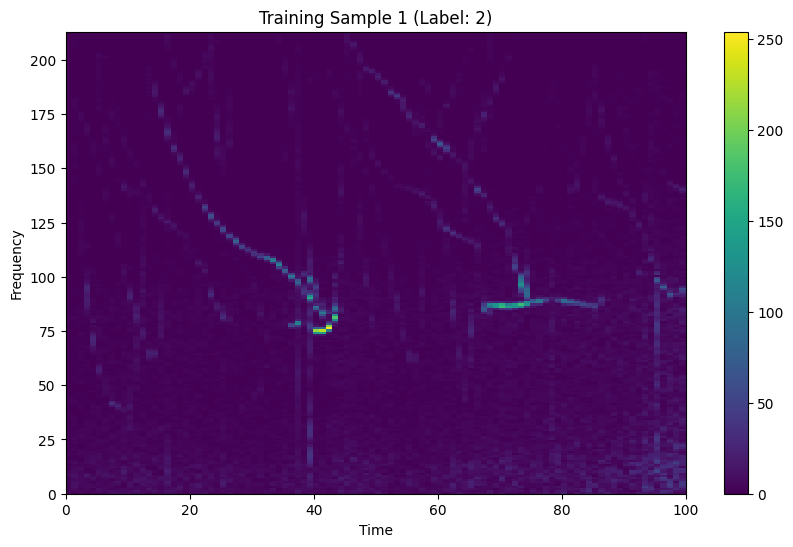


标签分布统计:
训练集: {0: 13623, 1: 18972, 2: 18810, 3: 18936}
验证集: {0: 936, 1: 1782, 2: 1872, 3: 1494}
测试集: {0: 4810, 1: 6462, 2: 5976, 3: 6840}


In [11]:
# ==========================================
# 可选：可视化检查（用于调试）
# ==========================================

# 显示第一个训练样本
plt.figure(figsize=(10, 6))
plt.pcolor(X_train[0, :, :, 0])
plt.colorbar()
plt.title(f'Training Sample 1 (Label: {y_train[0]})')
plt.xlabel('Time')
plt.ylabel('Frequency')

plt.show()

# 统计各标签数量
print("\n标签分布统计:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_val, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("训练集:", dict(zip(unique_train, counts_train)))
print("验证集:", dict(zip(unique_val, counts_val)))
print("测试集:", dict(zip(unique_test, counts_test)))